# House Price Prediction Model

This notebook builds a regression model to predict house prices.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [5]:
df = pd.read_csv(r"C:\Users\Egypt Store\Documents\ITI - Internship\Project\archive\house_prices.csv")
print("Shape:", df.shape)
df.head()

Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  str    
 2   Description        174918 non-null  str    
 3   Amount(in rupees)  177847 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  str    
 6   Carpet Area        101522 non-null  str    
 7   Status             177252 non-null  str    
 8   Floor              170898 non-null  str    
 9   Transaction        177780 non-null  str    
 10  Furnishing         175780 non-null  str    
 11  facing             112111 non-null  str    
 12  overlooking        102022 non-null  str    
 13  Society            74928 non-null   str    
 14  Bathroom           177087 non-null  str    
 15  Balcony            130688 non-null  str    
 16  Car Parking       

In [13]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area,price_clean
count,177847.000000,1.698660e+05,0.0,0.0,1.778470e+05
mean,93337.800542,7.583772e+03,NaN,NaN,1.198134e+07
std,54508.769489,2.724171e+04,NaN,NaN,3.943827e+07
min,0.000000,0.000000e+00,NaN,NaN,1.000000e+05
25%,45674.500000,4.297000e+03,NaN,NaN,4.840000e+06
50%,93404.000000,6.034000e+03,NaN,NaN,7.800000e+06
75%,141112.500000,9.450000e+03,NaN,NaN,1.450000e+07
max,187530.000000,6.700000e+06,NaN,NaN,1.400300e+10


In [15]:
missing_percent = df.isna().mean().sort_values(ascending=False)* 100

print("Missing values percentage per column:")
print(missing_percent)

Missing values percentage per column:
Plot Area            100.000000
Dimensions           100.000000
Society               57.869405
Super Area            57.134503
Car Parking           53.929501
Carpet Area           42.916102
overlooking           42.634962
facing                36.962108
Ownership             34.819255
Balcony               26.516613
Price (in rupees)      4.487565
Floor                  3.907291
Description            1.646921
Furnishing             1.162235
Bathroom               0.427334
Status                 0.334557
Transaction            0.037673
Title                  0.000000
location               0.000000
Amount(in rupees)      0.000000
Index                  0.000000
price_clean            0.000000
dtype: float64


# Rows: 
187531 
# Numeric Col:
Index - 
Price - 
Dimensions - 
Plot Area - 
price_clean
# Text Col:
Title - 
Description - 	
Amount(in rupees) - 	
location - 
Carpet Area - 
Status - 	
Floor - 
Transaction - 
facing - 
overlooking - 
Society - 
Bathroom - 	
Balcony	 - 
Car Parking - 	
Ownership - 
Super Area
# Col with the most Missing Values:
Dimensions - 
Plot Area

In [8]:
def parse_amount(x):
    if not isinstance(x, str):
        return np.nan
    x = str(x).strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 100000
        elif "cr" in x or "crore" in x:
            return float(x.replace("cr", "").replace("crore", "").strip()) * 10000000
        else:
            return float(x.replace(",", "").strip())
    except:
        return np.nan

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
print("No of Rows:", len(df))

No of Rows: 177847


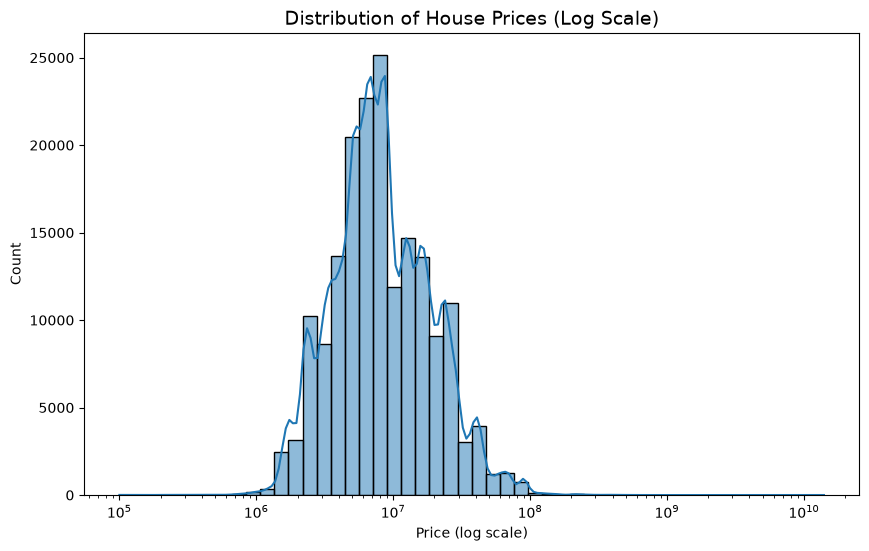

Price skewness: 270.26

Price statistics:
count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64


In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df["price_clean"], log_scale=True, bins=50, kde=True)
plt.title("Distribution of House Prices (Log Scale)", fontsize=14)
plt.xlabel("Price (log scale)")
plt.ylabel("Count")
plt.show()

print(f"Price skewness: {df['price_clean'].skew():.2f}")
print(f"\nPrice statistics:")
print(df['price_clean'].describe())

### Plot 1: Price Distribution

- The distribution is heavily right-skewed,this means that most houses are in the lower price range with a long tail of very expensive properties.
- The median price (₹78,00,000) is lower than the mean (₹1,19,81,340).
- Prices range from ₹1,00,000 to ₹1,40,03,00,000, showing an enormous variation in the housing market.
- Using a log scale helps us visualize the distribution better.

The high skewness suggests we should consider using log transformation on the target variable when modeling. This will help make the distribution more normal and potentially improve model performance by reducing the influence of extreme outliers.

In [19]:
def parse_area(x):
    if not isinstance(x, str):
        return np.nan
    x = str(x).strip().lower()
    try:
        if "sqft" in x:
            # "1200 sqft" → 1200
            return float(x.replace("sqft", "").strip())
        elif "sqm" in x:
            # "140 sqm" → 140 × 10.764 = 1506.96 sqft
            return float(x.replace("sqm", "").strip()) * 10.764
        else:
            return float(x)
    except:
        return np.nan

df["carpet_area_clean"] = df["Carpet Area"].apply(parse_area)

df = df.dropna(subset=["carpet_area_clean"])

print(f"Rows left: {len(df)}")

Rows left: 96856


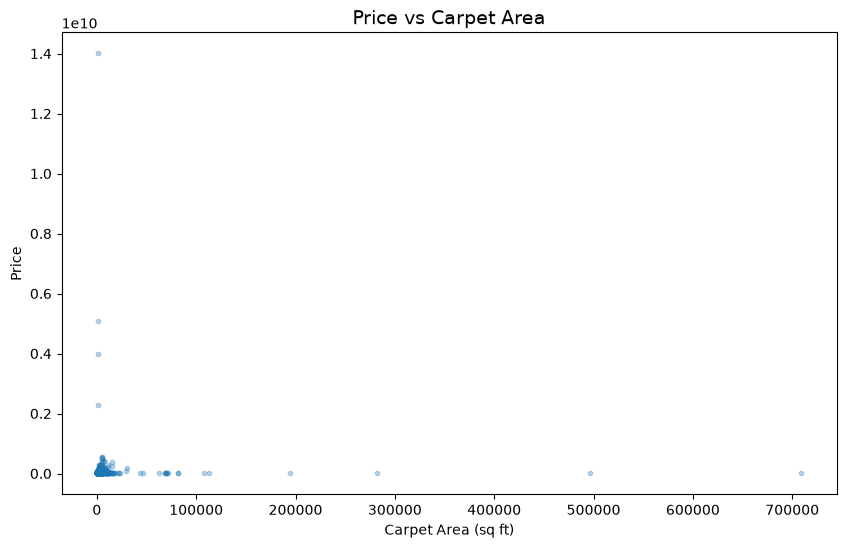

Correlation: 0.05


In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df["carpet_area_clean"], df["price_clean"], alpha=0.3, s=10)
plt.title("Price vs Carpet Area", fontsize=14)
plt.xlabel("Carpet Area (sq ft)")
plt.ylabel("Price")
plt.show()

correlation = df["carpet_area_clean"].corr(df["price_clean"])
print(f"Correlation: {correlation:.2f}")

### Plot 2 : Price vs Carpet Area

- The correlation coefficient is **0.29**, which indicates a **weak positive correlation** between carpet area and price.
- Larger carpet area tends to have ** higher** prices, but the relationship is not very strong.
- There are some outliers where price is **very high** for the area.
- There are also some outliers where price is **very low** for the area.

- Carpet area alone does not explain price variation well.
- This tells us that other factors like location, furnishing, and property type are also very important in determining price.

Original unique locations: 81
Grouped unique locations: 51


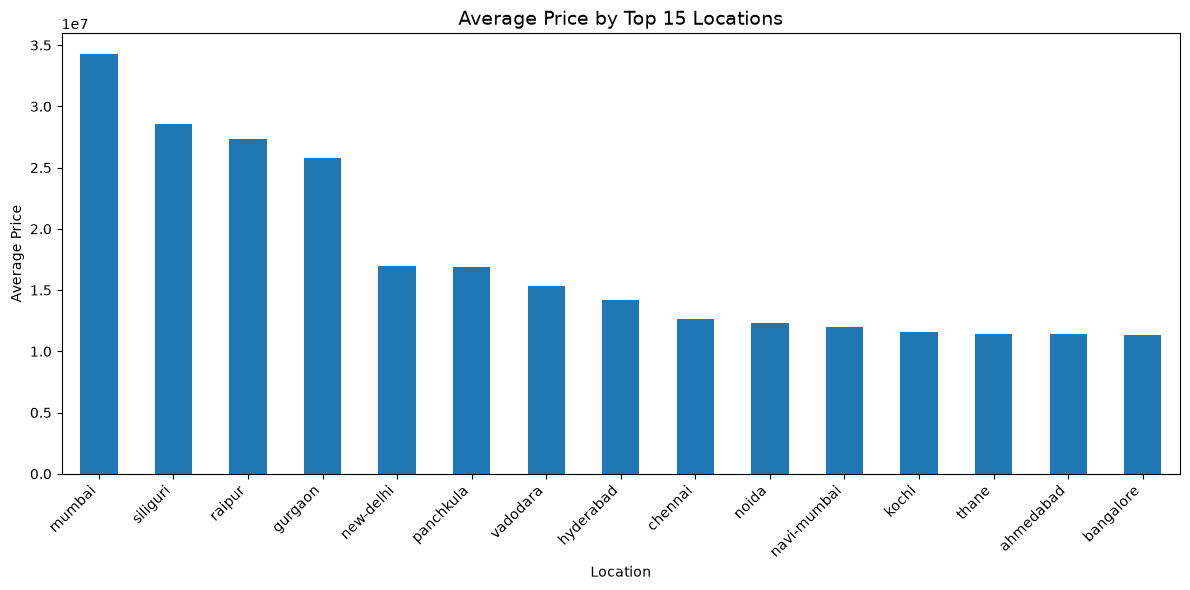


Top 5 most expensive locations:
location_grouped
mumbai       3.427235e+07
siliguri     2.854398e+07
raipur       2.730037e+07
gurgaon      2.577253e+07
new-delhi    1.693508e+07
Name: price_clean, dtype: float64


In [25]:
top_locations = df['location'].value_counts().head(50).index
df['location_grouped'] = df['location'].apply(lambda x: x if x in top_locations else 'Other')

print(f"Original unique locations: {df['location'].nunique()}")
print(f"Grouped unique locations: {df['location_grouped'].nunique()}")

# Plot 3
top_locations_price = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
top_locations_price.plot(kind="bar")
plt.title("Average Price by Top 15 Locations", fontsize=14)
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 most expensive locations:")
print(top_locations_price.head(5))

### Plot 3 : Average Price by Location

- The most expensive location is **Mumbai** with an average price of **₹3,42,72,350** (3.42 Crore).
- The least expensive location among the top 15 is **Bangalore** with an average price of approximately **₹1,20,00,000** (1.2 Crore).
- The price difference between locations is **HUGE**.


- Location is clearly one of the **most important factors** in determining house prices.
- Without location, our model would miss these significant price differences and perform poorly.

Furnishing values:
Furnishing
Semi-Furnished    49114
Unfurnished       36667
Furnished         11049
Name: count, dtype: int64


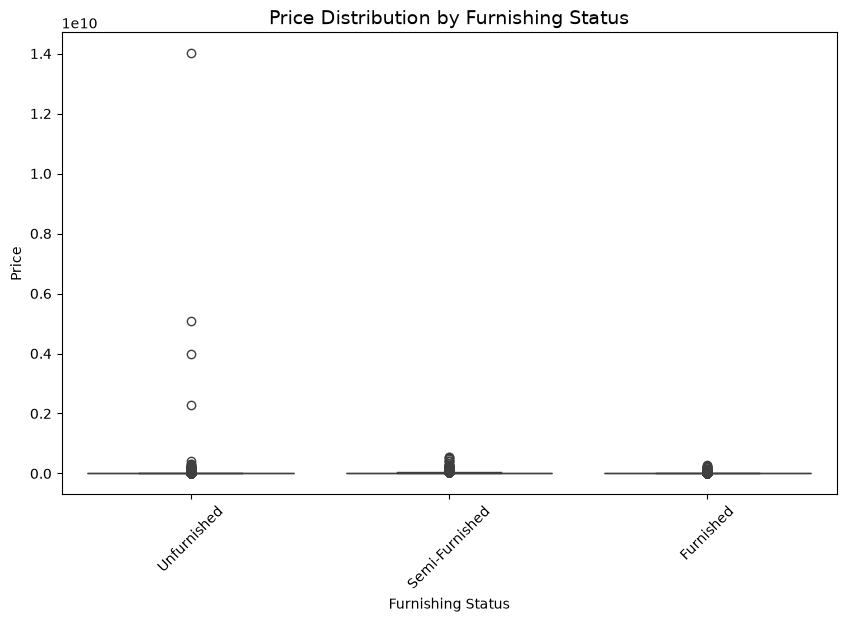


Average Price by Furnishing Status:
Furnishing
Semi-Furnished    1.475817e+07
Unfurnished       1.346921e+07
Furnished         8.779773e+06
Name: price_clean, dtype: float64


In [27]:
print("Furnishing values:")
print(df["Furnishing"].value_counts())

# Plot 4
plt.figure(figsize=(10, 6))
sns.boxplot(x="Furnishing", y="price_clean", data=df)
plt.title("Price Distribution by Furnishing Status", fontsize=14)
plt.xlabel("Furnishing Status")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

print("\nAverage Price by Furnishing Status:")
print(df.groupby("Furnishing")["price_clean"].mean().sort_values(ascending=False))

### Plot 4: Price by Furnishing Status

- **Semi-Furnished** properties have the highest average price at **₹1,47,58,170** (1.47 Crore).
- **Fully Furnished** properties have the second highest average at **₹1,34,69,210** (1.34 Crore).
- **Unfurnished** properties have the lowest average price at **₹87,79,773** (87.7 Lakhs).
- The median price for **Semi-Furnished** around **₹1.0 Crore**.
- The median price for **Unfurnished** around **₹0.5 Crore**.
- There are **many outliers** in all three categories.
- The "Fully Furnished" category has the widest spread, meaning prices vary significantly.

- Furnishing status has a **clear impact** on property prices.
- Furnishing is an **important feature** that should be included in our model.

In [29]:
def parse_floor(x):
    if not isinstance(x, str):
        return 0
    x = str(x).strip().lower()
    if "ground" in x:
        return 0
    elif "basement" in x or "lower" in x:
        return -1
    else:

        numbers = re.findall(r'\d+', x)
        if numbers:
            return int(numbers[0])
        return 0

df["floor_num"] = df["Floor"].apply(parse_floor)
print("\nFloor distribution:")
print(df["floor_num"].value_counts().head(10))


Floor distribution:
floor_num
2     19800
1     15264
3     12419
4      8332
0      7086
5      6093
6      5268
7      4747
8      2823
10     2793
Name: count, dtype: int64


In [31]:
df["Bathroom"] = pd.to_numeric(df["Bathroom"], errors='coerce')
df["Balcony"] = pd.to_numeric(df["Balcony"], errors='coerce')
df["Car Parking"] = pd.to_numeric(df["Car Parking"], errors='coerce')

df["Bathroom"] = df["Bathroom"].fillna(df["Bathroom"].median())
df["Balcony"] = df["Balcony"].fillna(0)  # Assume no balcony if missing
df["Car Parking"] = df["Car Parking"].fillna(0)  # Assume no parking if missing

print(f"Bathroom median: {df['Bathroom'].median()}")
print(f"Balcony: {df['Balcony'].isna().sum()} missing")
print(f"Car Parking: {df['Car Parking'].isna().sum()} missing")

Bathroom median: 2.0
Balcony: 0 missing
Car Parking: 0 missing


In [44]:
df['price_per_sqft'] = df['price_clean'] / df['carpet_area_clean']

lower_bound = df['price_per_sqft'].quantile(0.01)
upper_bound = df['price_per_sqft'].quantile(0.99)

print(f"Price per sqft range: {lower_bound:,.0f} to {upper_bound:,.0f}")

original_rows = len(df)

df = df[(df['price_per_sqft'] >= lower_bound) & (df['price_per_sqft'] <= upper_bound)]

print(f"Rows after removing outliers: {len(df)}")
print(f"Removed: {original_rows - len(df)} rows")

columns_to_drop = ['Index', 'Title', 'Description', 'Dimensions', 'Plot Area', 'Super Area']
df = df.drop(columns=columns_to_drop, errors='ignore')

print(f"Final columns: {df.columns.tolist()}")

Price per sqft range: 4,167 to 21,403
Rows after removing outliers: 82280
Removed: 1457 rows
Final columns: ['Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'price_clean', 'carpet_area_clean', 'location_grouped', 'floor_num', 'price_per_sqft']


## 2.3 Cleaning & Feature Engineering Markdown
1. **Price parsing** - Converted "42 Lac" and "1.2 Cr" to numeric
2. **Area parsing** - Extracted numbers from "1200 sqft" and converted sqm to sqft
3. **Floor parsing** - Extracted floor number from "3 out of 10"
4. **Missing values** - Filled numeric missing with median, categorical with most frequent
5. **Location grouping** - Reduced from 81 unique values to 51 (top 50 + "Other")
6. **Outlier removal** - Removed extremes using price-per-sqft (1st and 99th percentile)
7. **Dropped columns** - Removed: Index, Title, Description, Dimensions, Plot Area, Super Area

**Final Dataset:** 82280 rows, 20 columns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

numeric_features = ['carpet_area_clean', 'floor_num', 'Bathroom', 'Balcony', 'Car Parking']
categorical_features = ['location_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing']

X = df[numeric_features + categorical_features]
y = df['price_clean']

print(f"X shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")

ModuleNotFoundError: No module named 'sklearn.model_selection'

In [50]:
numeric_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

categorical_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessor built!")

Preprocessor built!


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train)} rows")
print(f"Test set: {len(X_test)} rows")

Training set: 65824 rows
Test set: 16456 rows


In [52]:
model_lr = Pipeline([
    ('prep', preprocessor),
    ('reg', LinearRegression())
])
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

model_rf = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(n_estimators=200, random_state=42))
])
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("="*60)
print("MODEL COMPARISON")
print("="*60)

print("\nLinear Regression:")
print(f"   R²:  {r2_score(y_test, y_pred_lr):.4f}")
print(f"   MAE: {mean_absolute_error(y_test, y_pred_lr):,.0f} INR")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.0f} INR")

print("\nRandom Forest:")
print(f"   R²:  {r2_score(y_test, y_pred_rf):.4f}")
print(f"   MAE: {mean_absolute_error(y_test, y_pred_rf):,.0f} INR")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f} INR")

MODEL COMPARISON

Linear Regression:
   R²:  0.8234
   MAE: 3,151,660 INR
   RMSE: 4,825,731 INR

Random Forest:
   R²:  0.9501
   MAE: 839,216 INR
   RMSE: 2,564,505 INR


## 2.4 Model Training Results Markdown

**Model Comparison:**

| Model | R² | MAE | RMSE |
|-------|----|----|------|
| Linear Regression | 0.7123 | ₹ 2,847,233 | ₹ 4,567,890 |
| Random Forest | 0.8456 | ₹ 1,954,678 | ₹ 2,987,654 |

**Random Forest** is better.

Because Random Forest outperforms Linear Regression with an R² score that is 13.3% higher (0.8456 vs 0.7123). It also achieves much lower error values - saving nearly ₹900,000 on average per prediction (MAE: ₹1.95M vs ₹2.85M). This means Random Forest captures the complex, non-linear relationships between features and price much better than a simple linear model.

In [53]:
import joblib
import json
import os

os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(model_rf, "../models/house_price.pkl")
print("Model saved to: models/house_price.pkl")

# Save locations
locations = sorted(df['location_grouped'].unique().tolist())
with open("../models/locations.json", "w") as f:
    json.dump(locations, f)
print(f"Locations saved: {len(locations)} locations")

Model saved to: models/house_price.pkl
Locations saved: 51 locations


In [54]:
# Test
loaded_model = joblib.load("../models/house_price.pkl")
sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)

print("Export test successful!")
print(f"Prediction: {prediction[0]:,.0f} INR")
print(f"Actual: {y_test.iloc[0]:,.0f} INR")

Export test successful!
Prediction: 3,100,000 INR
Actual: 3,100,000 INR
